# Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=0.95)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

df = pd.read_parquet('rawg_clean.parquet')
df['released'] = pd.to_datetime(df['released'], errors='coerce')
df['updated'] = pd.to_datetime(df['updated'], errors='coerce')

def explode_col(df, col, sep='|'):
    """Explode a pipe-delimited column into long format."""
    return (
        df.dropna(subset=[col])
        .assign(**{col: lambda x: x[col].str.split(sep)})
        .explode(col)
        .assign(**{col: lambda x: x[col].str.strip()})
    )

print(f"Shape: {df.shape}")

Shape: (12207, 49)


---
# Part 1 — General Statistics
## 1.1 Data overview & completeness

In [20]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,12207.0,NaN,NaN,NaN,126158.243713,2.0,12283.0,25663.0,58764.5,1003457.0,221461.808473
name,12207,12206,Jack N Jill DX,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
released,12207,NaN,NaN,NaN,2012-07-01 22:44:37.217989,1962-01-01 00:00:00,2008-07-31 12:00:00,2014-10-08 00:00:00,2018-02-06 12:00:00,2026-05-26 00:00:00,NaN
rating,12207.0,NaN,NaN,NaN,3.427257,1.0,3.0,3.56,3.97,4.82,0.703183
ratings_count,12207.0,NaN,NaN,NaN,134.801917,11.0,18.0,35.0,96.0,7153.0,344.68394
reviews_text_count,5495.0,NaN,NaN,NaN,3.733394,1.0,1.0,2.0,3.0,124.0,6.743283
added,12207.0,NaN,NaN,NaN,907.302122,9.0,138.0,370.0,916.5,22126.0,1623.843949
playtime,9033.0,NaN,NaN,NaN,5.228828,1.0,1.0,3.0,4.0,900.0,17.388223
suggestions_count,12181.0,NaN,NaN,NaN,377.927838,1.0,242.0,372.0,508.0,1729.0,181.189448
updated,12207,NaN,NaN,NaN,2024-10-24 12:47:47.185713,2019-01-09 12:41:06,2024-07-06 00:43:41,2025-03-24 17:25:10,2025-06-11 17:24:36,2025-07-19 13:57:35,NaN


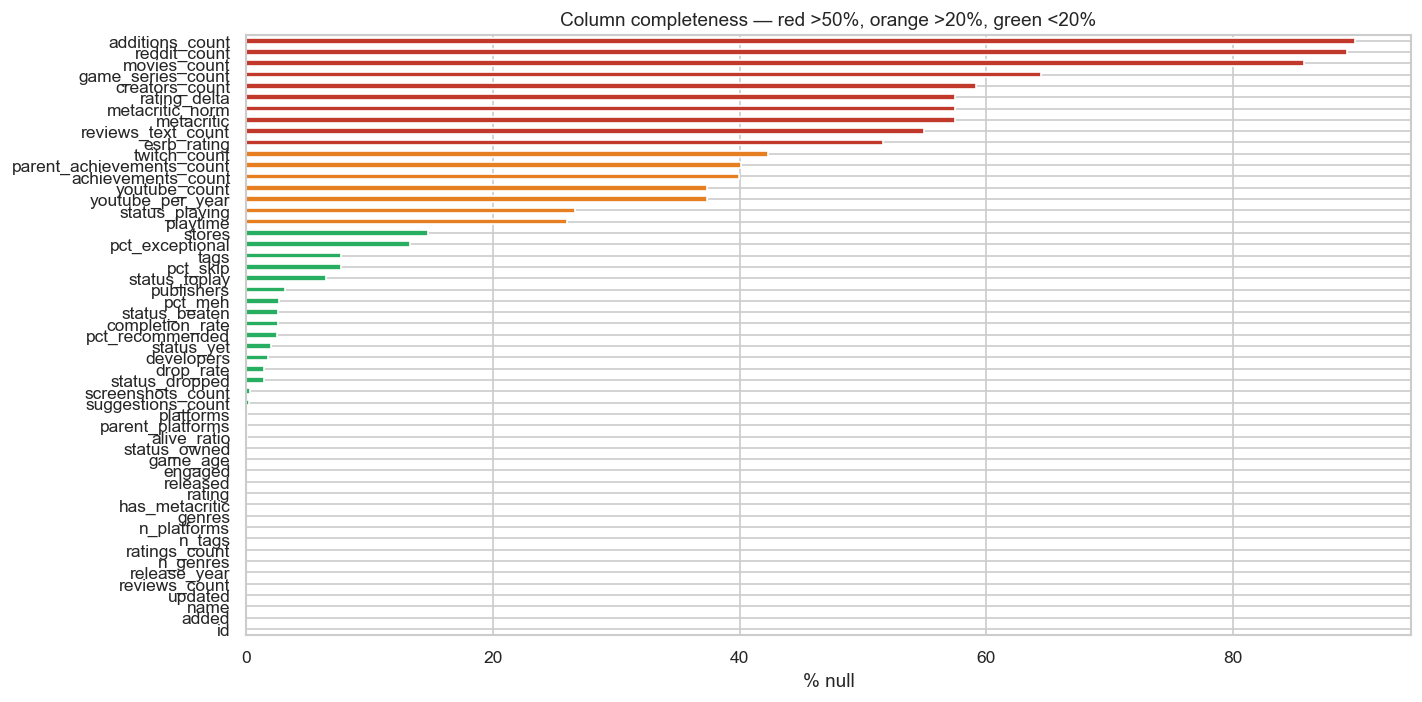

Fully complete columns: 17
Columns >50% null: 10


In [21]:
# Column completeness — which columns can we rely on?
null_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#c0392b' if v > 50 else '#e67e22' if v > 20 else '#27ae60' for v in null_pct.values]
null_pct.plot.barh(ax=ax, color=colors)
ax.set_xlabel('% null')
ax.set_title('Column completeness — red >50%, orange >20%, green <20%')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Fully complete columns: {(null_pct == 0).sum()}")
print(f"Columns >50% null: {(null_pct > 50).sum()}")

## 1.2 Temporal landscape

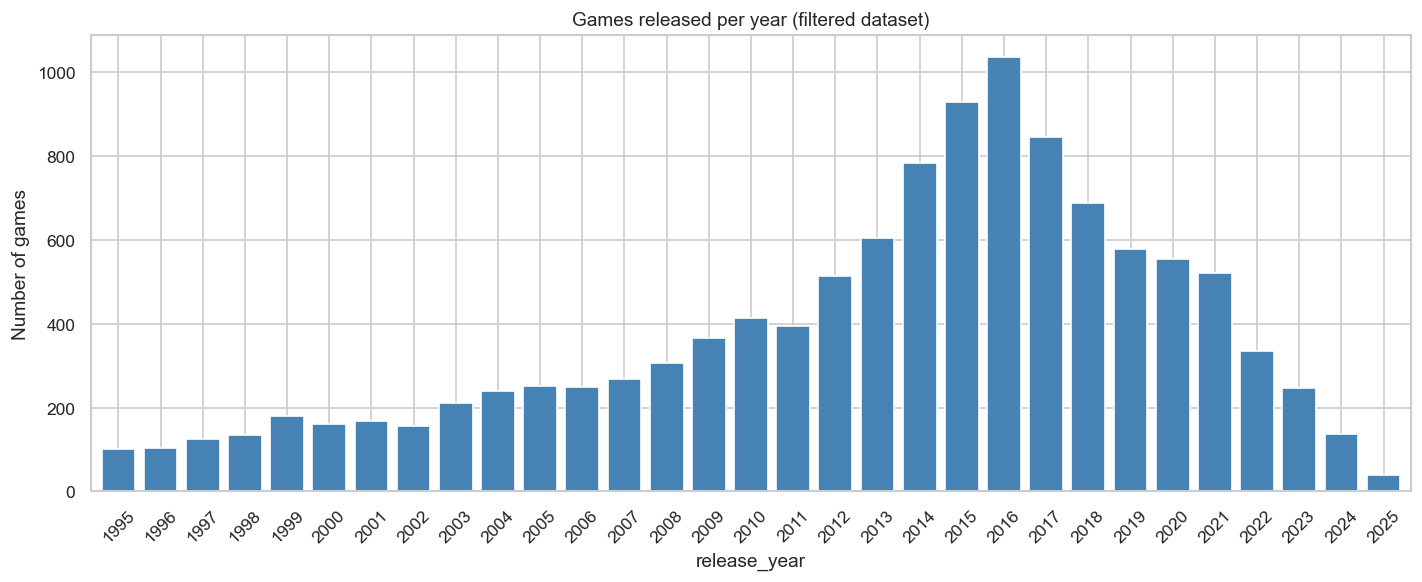

Peak year: 2016 (1037 games)
Post-2020 taper is likely a recency filter artifact — newer games haven't accumulated >10 ratings yet.


In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
yearly = df[df['release_year'].between(1995, 2025)].groupby('release_year').size()
yearly.plot.bar(ax=ax, color='steelblue', width=0.8)
ax.set_ylabel('Number of games')
ax.set_title('Games released per year (filtered dataset)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

peak_year = yearly.idxmax()
print(f"Peak year: {peak_year} ({yearly.max()} games)")
print(f"Post-2020 taper is likely a recency filter artifact — newer games haven't accumulated >10 ratings yet.")

## 1.3 Rating distributions

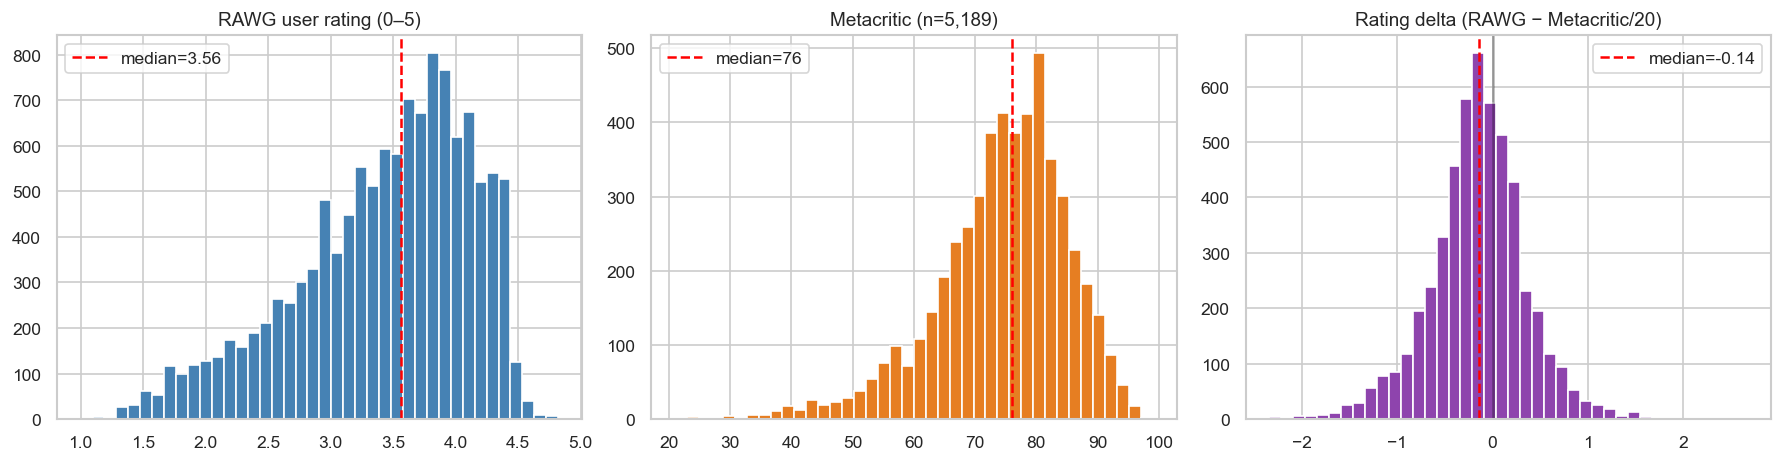

Both ratings skew positive.
Delta < 0 → critics liked it more. Delta > 0 → players liked it more.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RAWG rating
df['rating'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['rating'].median(), color='red', linestyle='--', label=f"median={df['rating'].median():.2f}")
axes[0].set_title('RAWG user rating (0–5)')
axes[0].legend()

# Metacritic
df['metacritic'].dropna().hist(bins=40, ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].axvline(df['metacritic'].dropna().median(), color='red', linestyle='--',
                label=f"median={df['metacritic'].dropna().median():.0f}")
axes[1].set_title(f"Metacritic (n={df['metacritic'].notna().sum():,})")
axes[1].legend()

# Rating delta
delta = df['rating_delta'].dropna()
delta.hist(bins=40, ax=axes[2], color='#8e44ad', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='-', alpha=0.3)
axes[2].axvline(delta.median(), color='red', linestyle='--', label=f"median={delta.median():.2f}")
axes[2].set_title('Rating delta (RAWG − Metacritic/20)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Both ratings skew positive.")
print(f"Delta < 0 → critics liked it more. Delta > 0 → players liked it more.")

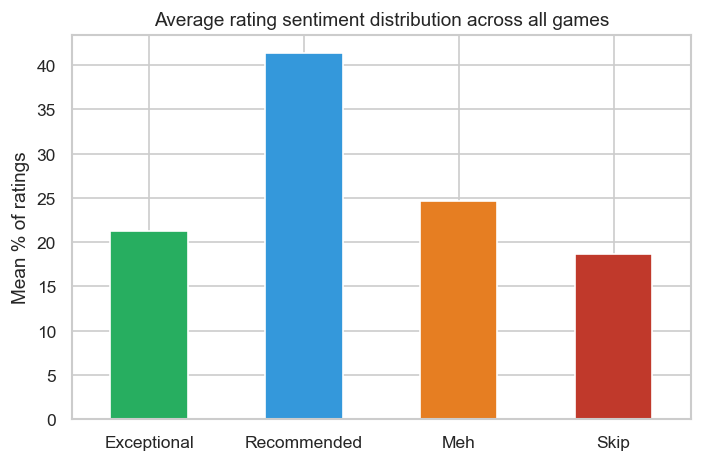

In [24]:
# Sentiment breakdown — average distribution of exceptional/recommended/meh/skip
sentiment_cols = ['pct_exceptional', 'pct_recommended', 'pct_meh', 'pct_skip']
sentiment_means = df[sentiment_cols].mean()
sentiment_means.index = ['Exceptional', 'Recommended', 'Meh', 'Skip']

fig, ax = plt.subplots(figsize=(6, 4))
sentiment_means.plot.bar(ax=ax, color=['#27ae60', '#3498db', '#e67e22', '#c0392b'])
ax.set_ylabel('Mean % of ratings')
ax.set_title('Average rating sentiment distribution across all games')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 1.4 Genre and platform landscape

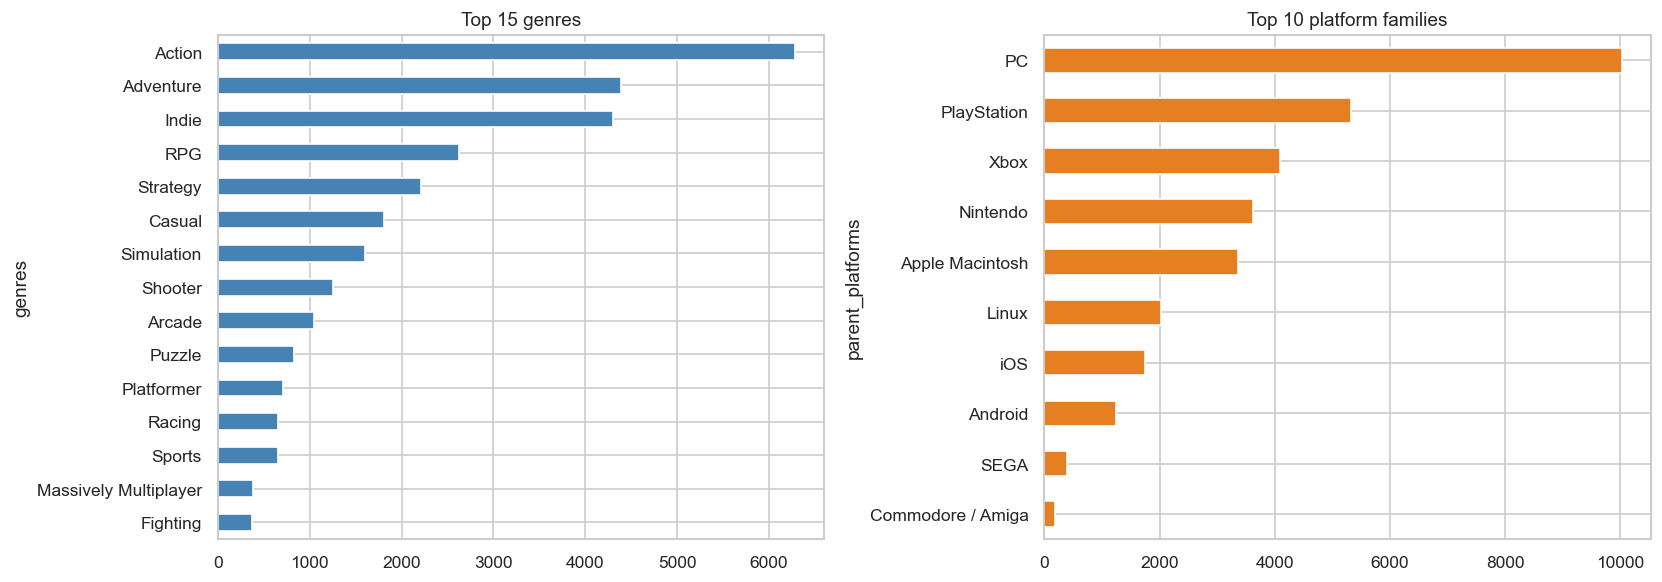

Average genres per game: 2.4
Average platforms per game: 3.0


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top genres
genre_counts = explode_col(df, 'genres')['genres'].value_counts().head(15)
genre_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 genres')
axes[0].invert_yaxis()

# Top parent platforms
plat_counts = explode_col(df, 'parent_platforms')['parent_platforms'].value_counts().head(10)
plat_counts.plot.barh(ax=axes[1], color='#e67e22')
axes[1].set_title('Top 10 platform families')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Average genres per game: {df['n_genres'].mean():.1f}")
print(f"Average platforms per game: {df['n_platforms'].mean():.1f}")

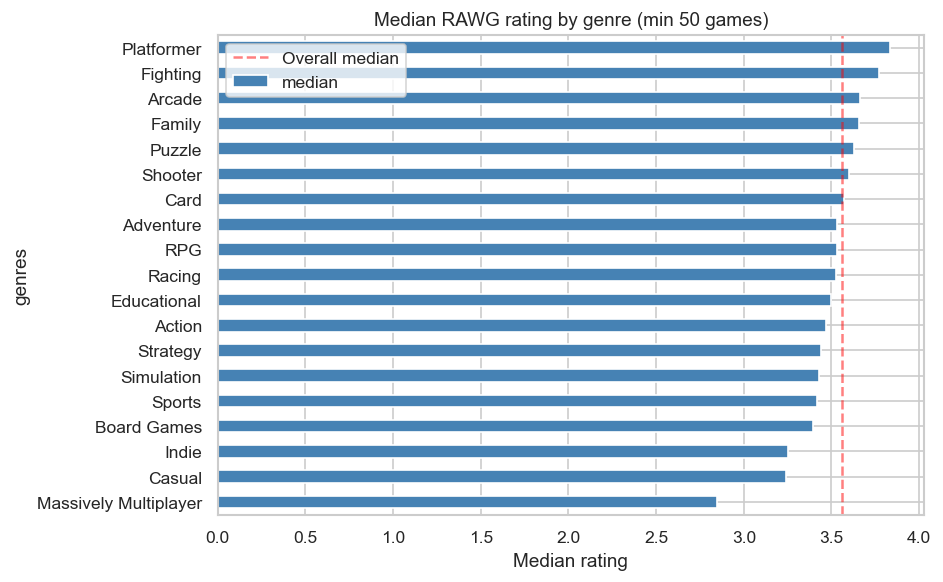

In [26]:
# Median rating by genre
genre_ratings = (
    explode_col(df, 'genres')
    .groupby('genres')['rating']
    .agg(['median', 'count'])
    .query('count >= 50')
    .sort_values('median', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
genre_ratings['median'].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Median rating')
ax.set_title('Median RAWG rating by genre (min 50 games)')
ax.axvline(df['rating'].median(), color='red', linestyle='--', alpha=0.5, label='Overall median')
ax.legend()
plt.tight_layout()
plt.show()

## 1.5 ESRB and content ratings

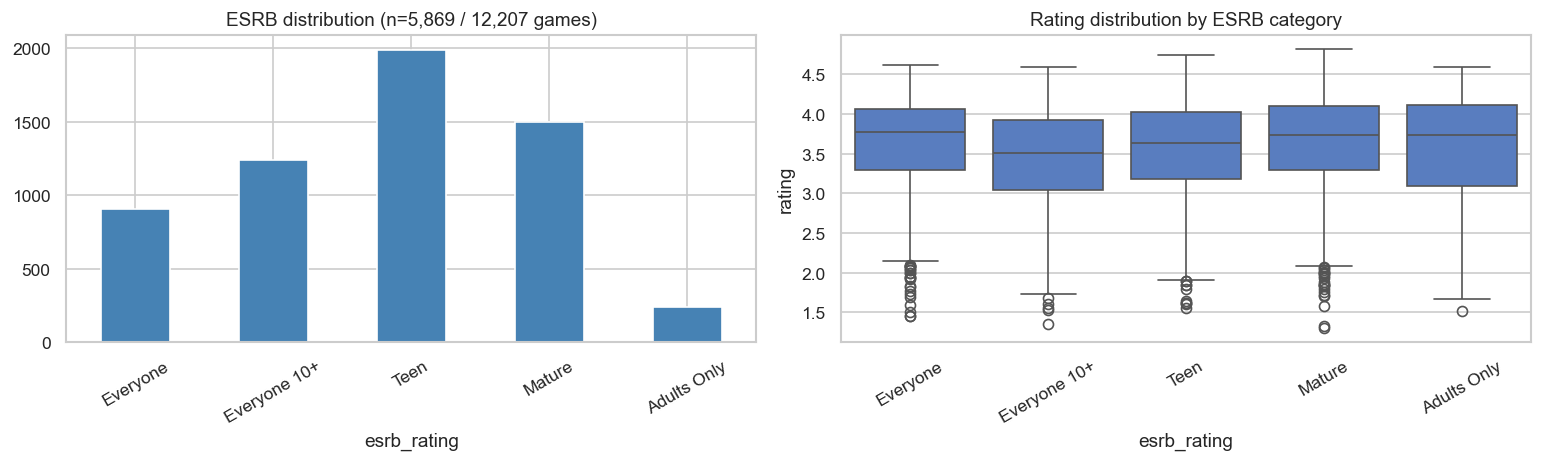

In [27]:
esrb_order = ['Everyone', 'Everyone 10+', 'Teen', 'Mature', 'Adults Only']
esrb_df = df[df['esrb_rating'].isin(esrb_order)].copy()
esrb_df['esrb_rating'] = pd.Categorical(esrb_df['esrb_rating'], categories=esrb_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

esrb_df['esrb_rating'].value_counts().reindex(esrb_order).plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title(f'ESRB distribution (n={len(esrb_df):,} / {len(df):,} games)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=esrb_df, x='esrb_rating', y='rating', ax=axes[1], order=esrb_order)
axes[1].set_title('Rating distribution by ESRB category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 1.6 Correlation overview

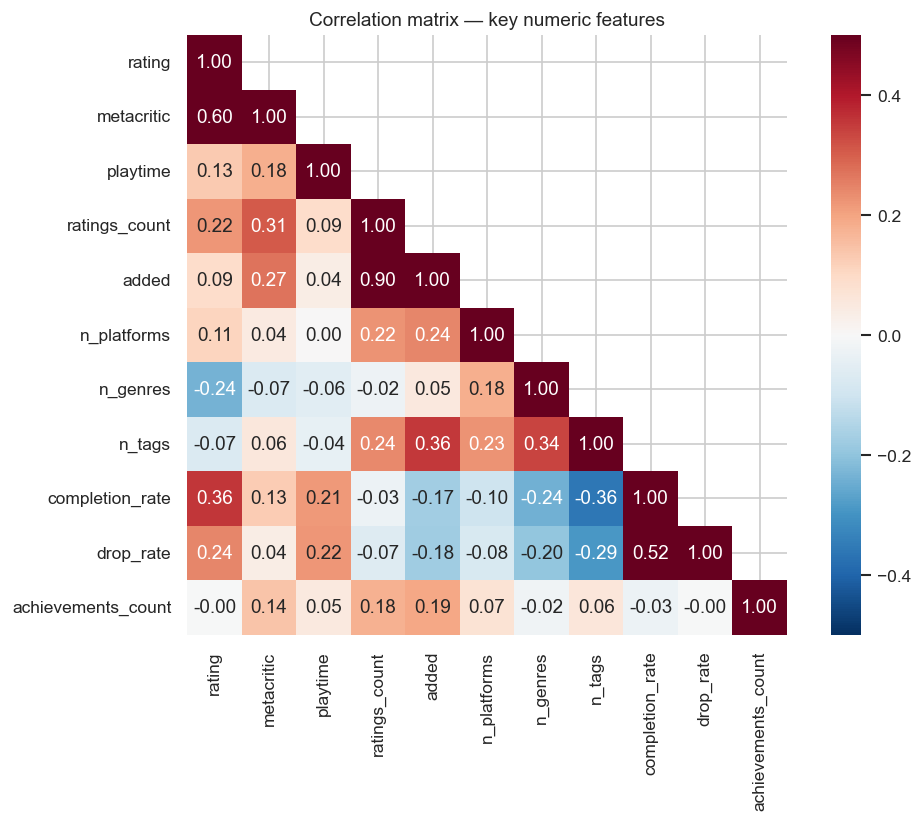

In [28]:
corr_cols = ['rating', 'metacritic', 'playtime', 'ratings_count', 'added',
             'n_platforms', 'n_genres', 'n_tags', 'completion_rate', 'drop_rate',
             'achievements_count']
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask_tri = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask_tri, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, square=True, ax=ax)
ax.set_title('Correlation matrix — key numeric features')
plt.tight_layout()
plt.show()

## 1.7 Playtime and community signals

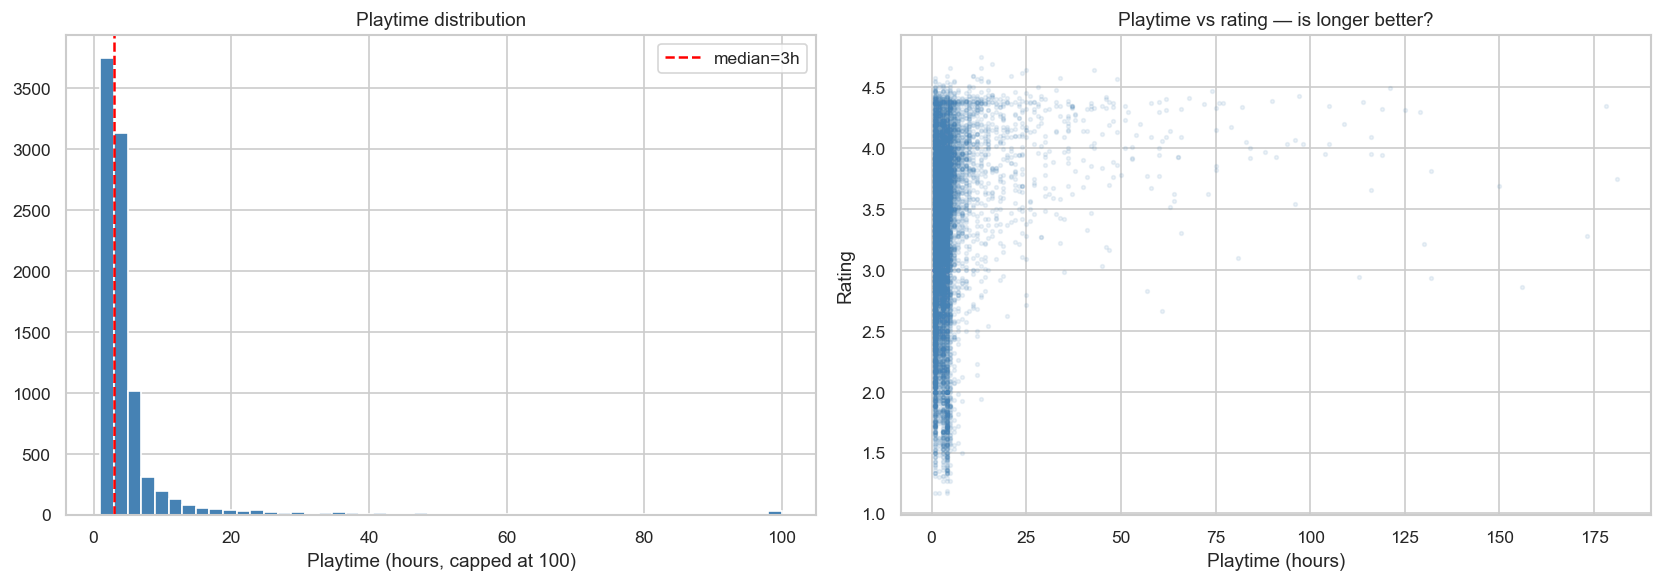

Median playtime: 3 hours
Games with >100h playtime: 32


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Playtime distribution
playtime = df['playtime'].dropna().clip(upper=100)
playtime.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(playtime.median(), color='red', linestyle='--', label=f"median={df['playtime'].dropna().median():.0f}h")
axes[0].set_xlabel('Playtime (hours, capped at 100)')
axes[0].set_title('Playtime distribution')
axes[0].legend()

# Playtime vs rating
mask = df['playtime'].notna() & df['playtime'].between(1, 200)
axes[1].scatter(df.loc[mask, 'playtime'], df.loc[mask, 'rating'], alpha=0.1, s=5, c='steelblue')
axes[1].set_xlabel('Playtime (hours)')
axes[1].set_ylabel('Rating')
axes[1].set_title('Playtime vs rating — is longer better?')

plt.tight_layout()
plt.show()

print(f"Median playtime: {df['playtime'].dropna().median():.0f} hours")
print(f"Games with >100h playtime: {(df['playtime'] > 100).sum()}")

Community signal coverage:
  youtube_count: 63% of games
  twitch_count: 58% of games
  reddit_count: 11% of games


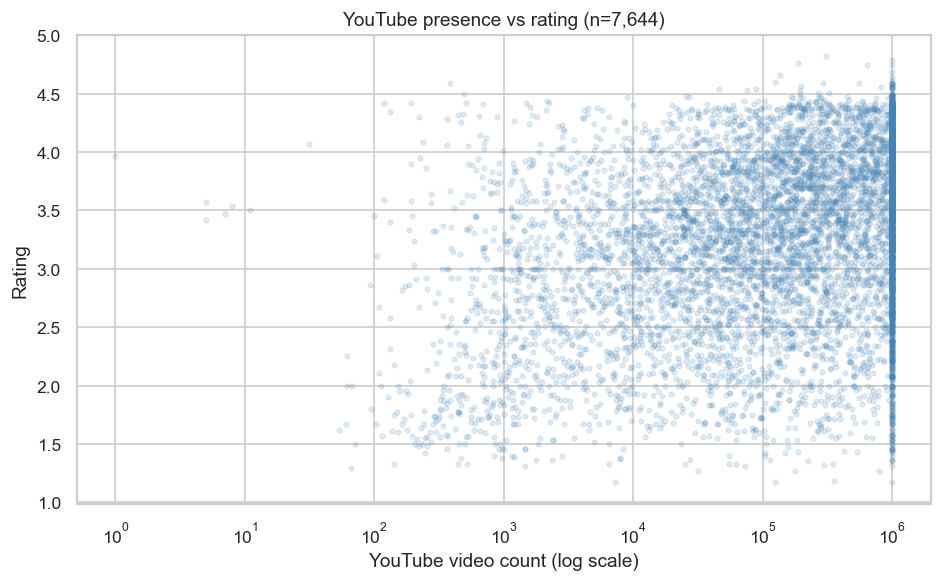


YouTube presence correlates weakly with rating — popular games get coverage regardless of quality.


In [30]:
# Community signal coverage
community_cols = ['youtube_count', 'twitch_count', 'reddit_count']
print("Community signal coverage:")
for col in community_cols:
    print(f"  {col}: {df[col].notna().mean()*100:.0f}% of games")

# YouTube vs rating (best coverage)
fig, ax = plt.subplots(figsize=(8, 5))
mask = df['youtube_count'].notna() & (df['youtube_count'] > 0)
ax.scatter(df.loc[mask, 'youtube_count'], df.loc[mask, 'rating'], alpha=0.15, s=8, c='steelblue')
ax.set_xscale('log')
ax.set_xlabel('YouTube video count (log scale)')
ax.set_ylabel('Rating')
ax.set_title(f'YouTube presence vs rating (n={mask.sum():,})')
plt.tight_layout()
plt.show()

print(f"\nYouTube presence correlates weakly with rating — popular games get coverage regardless of quality.")

# Use Case-focused analysis
The general stats reveal standard patterns (positive rating skew, genre dominance, sparsity). The more interesting findings come from the dataset's unique features which helps us analyze player lifecycle tendancies and the ability to cross-reference current activity with release date.

## 2.1 Most games are never finished
The `added_by_status` fields give us a direct window into what happens after someone acquires a game.

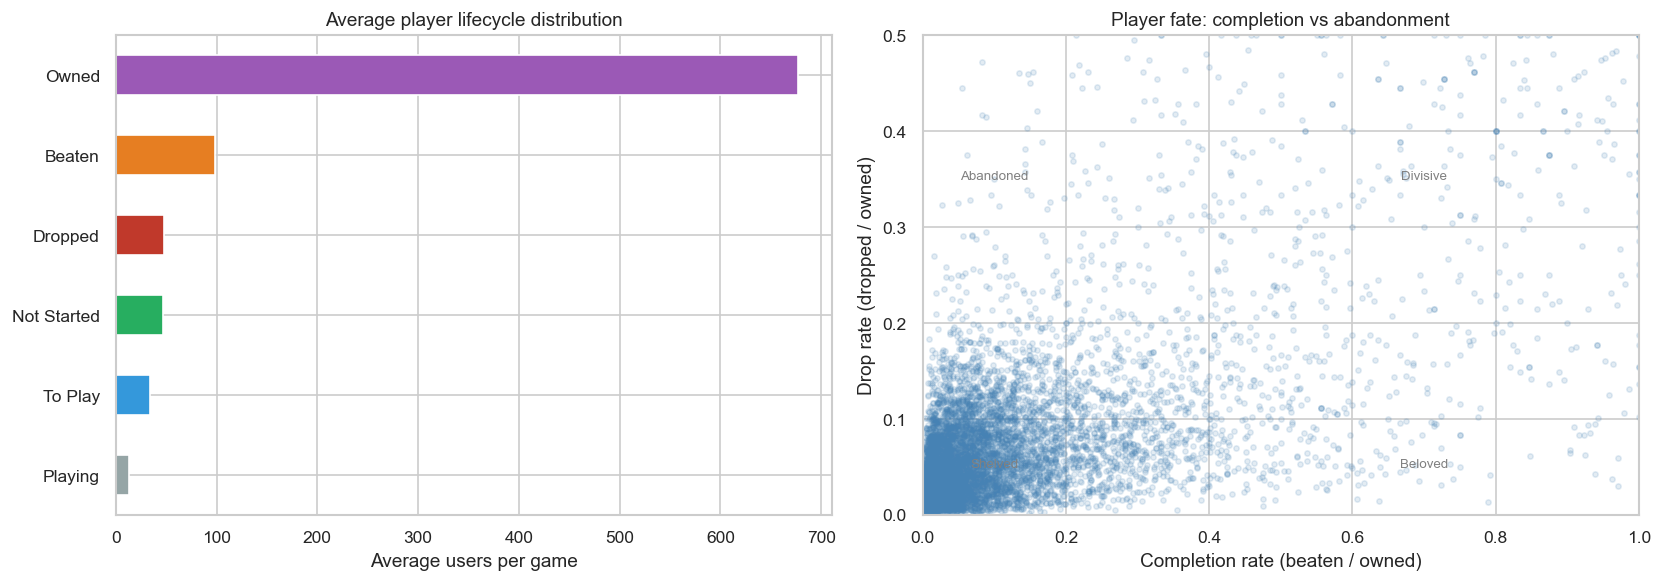

Median completion rate (beaten/owned): 9.1%
Median drop rate (dropped/owned): 6.6%
The vast majority of owned games are never finished.


In [32]:
# Player lifecycle: average breakdown
status_cols = ['status_owned', 'status_beaten', 'status_playing', 'status_dropped', 'status_toplay', 'status_yet']
status_means = df[status_cols].mean()
status_means.index = ['Owned', 'Beaten', 'Playing', 'Dropped', 'To Play', 'Not Started']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of average lifecycle
status_means.sort_values().plot.barh(ax=axes[0],
    color=['#95a5a6', '#3498db', '#27ae60', '#c0392b', '#e67e22', '#9b59b6'])
axes[0].set_xlabel('Average users per game')
axes[0].set_title('Average player lifecycle distribution')

# Completion vs drop scatter
mask = df['completion_rate'].notna() & df['drop_rate'].notna()
axes[1].scatter(df.loc[mask, 'completion_rate'], df.loc[mask, 'drop_rate'],
                alpha=0.15, s=10, c='steelblue')
axes[1].set_xlabel('Completion rate (beaten / owned)')
axes[1].set_ylabel('Drop rate (dropped / owned)')
axes[1].set_title('Player fate: completion vs abandonment')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 0.5)
axes[1].text(0.7, 0.35, 'Divisive', ha='center', fontsize=8, color='gray')
axes[1].text(0.7, 0.05, 'Beloved', ha='center', fontsize=8, color='gray')
axes[1].text(0.1, 0.35, 'Abandoned', ha='center', fontsize=8, color='gray')
axes[1].text(0.1, 0.05, 'Shelved', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print(f"Median completion rate (beaten/owned): {df['completion_rate'].median():.1%}")
print(f"Median drop rate (dropped/owned): {df['drop_rate'].median():.1%}")
print(f"The vast majority of owned games are never finished.")

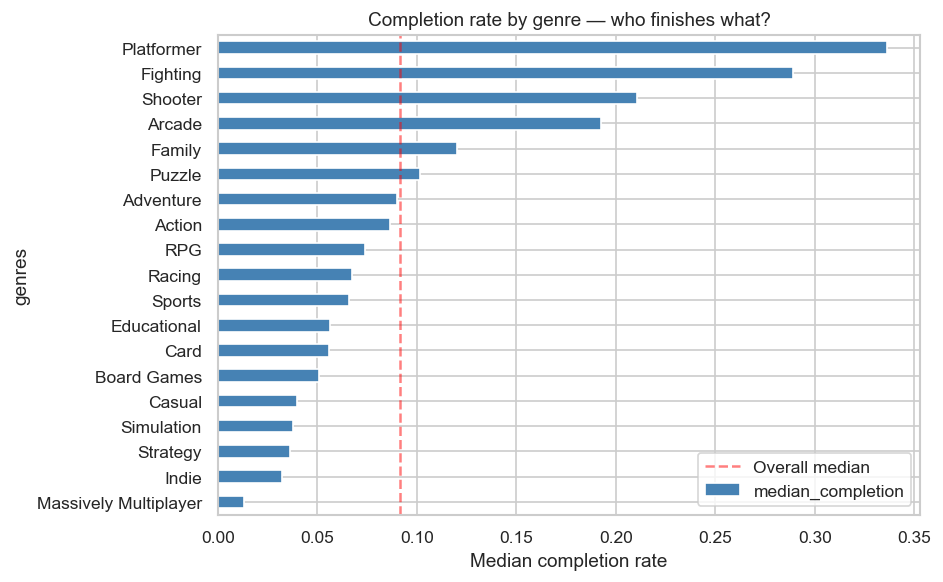

Genres at the bottom (MMO, Sports, Simulation) are designed to be played indefinitely, not 'beaten'.
This raises the question: is low completion a sign of failure — or of a different kind of success?


In [33]:
# Which genres have the highest / lowest completion?
genre_lifecycle = (
    explode_col(df, 'genres')
    .groupby('genres')
    .agg(
        median_completion=('completion_rate', 'median'),
        median_drop=('drop_rate', 'median'),
        n=('id', 'count')
    )
    .query('n >= 50')
    .sort_values('median_completion', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
genre_lifecycle['median_completion'].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Median completion rate')
ax.set_title('Completion rate by genre — who finishes what?')
ax.axvline(df['completion_rate'].median(), color='red', linestyle='--', alpha=0.5, label='Overall median')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Genres at the bottom (MMO, Sports, Simulation) are designed to be played indefinitely, not 'beaten'.")
print(f"This raises the question: is low completion a sign of failure — or of a different kind of success?")

Combining `status_playing` with release date to plot how games have sur

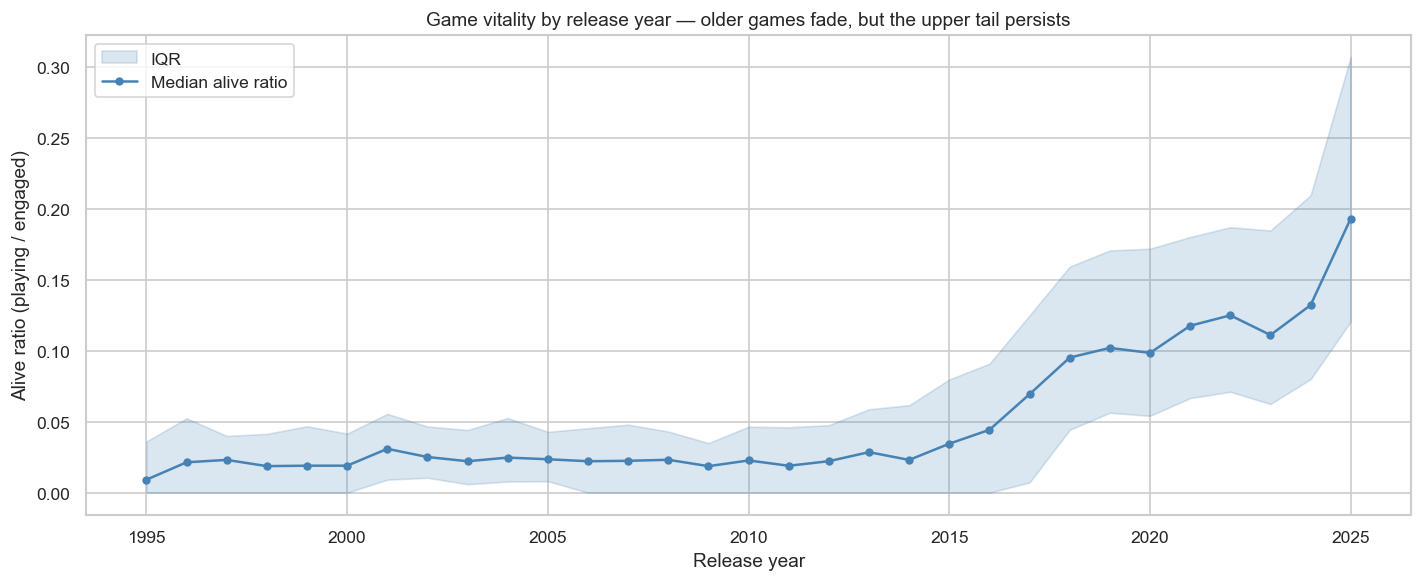

Overall median alive_ratio: 0.040
Only 4% of a typical game's engaged audience is still active.
But note the upper quartile (p75) — even among older years, some games stay alive.


In [34]:
# alive_ratio: fraction of engaged players still actively playing
df['engaged'] = df['status_playing'].fillna(0) + df['status_beaten'].fillna(0) + df['status_dropped'].fillna(0)
df['alive_ratio'] = np.where(df['engaged'] > 0, df['status_playing'].fillna(0) / df['engaged'], np.nan)
df['game_age'] = (pd.Timestamp.now() - df['released']).dt.days / 365.25

# Decay curve by release year
decay = (
    df[df['alive_ratio'].notna() & df['release_year'].between(1995, 2025)]
    .groupby('release_year')
    .agg(
        median_alive=('alive_ratio', 'median'),
        p75=('alive_ratio', lambda x: x.quantile(0.75)),
        p25=('alive_ratio', lambda x: x.quantile(0.25)),
        n=('alive_ratio', 'count')
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(decay.index, decay['p25'], decay['p75'], alpha=0.2, color='steelblue', label='IQR')
ax.plot(decay.index, decay['median_alive'], 'o-', color='steelblue', markersize=4, label='Median alive ratio')
ax.set_xlabel('Release year')
ax.set_ylabel('Alive ratio (playing / engaged)')
ax.set_title('Game vitality by release year — older games fade, but the upper tail persists')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Overall median alive_ratio: {df['alive_ratio'].median():.3f}")
print(f"Only 4% of a typical game's engaged audience is still active.")
print(f"But note the upper quartile (p75) — even among older years, some games stay alive.")

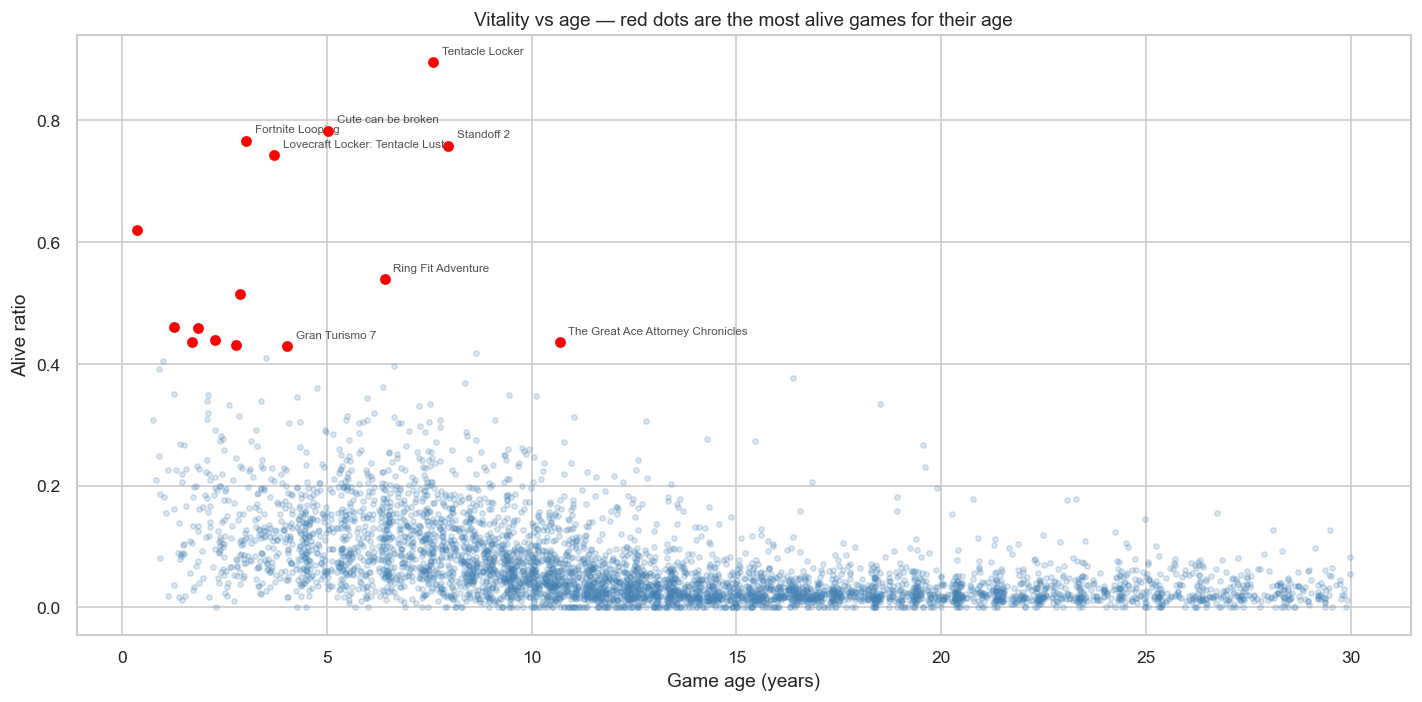

Games like League of Legends (2009), osu! (2007), and Europa Universalis IV (2013)
maintain vitality levels comparable to recent releases.


In [16]:
# Age vs vitality scatter — who are the outliers?
mask = df['alive_ratio'].notna() & df['game_age'].between(0, 30) & (df['engaged'] >= 50)
plot_df = df[mask]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(plot_df['game_age'], plot_df['alive_ratio'], alpha=0.2, s=10, c='steelblue')

# Highlight top outliers
outliers = plot_df.nlargest(15, 'alive_ratio')
ax.scatter(outliers['game_age'], outliers['alive_ratio'], c='red', s=30, zorder=5)
for _, row in outliers.iterrows():
    if row['game_age'] > 3:
        ax.annotate(row['name'], (row['game_age'], row['alive_ratio']),
                    fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Game age (years)')
ax.set_ylabel('Alive ratio')
ax.set_title('Vitality vs age — red dots are the most alive games for their age')
plt.tight_layout()
plt.show()

print(f"Games like League of Legends (2009), osu! (2007), and Europa Universalis IV (2013)")
print(f"maintain vitality levels comparable to recent releases.")

## 2.3 The games people never finish might be the ones that survive
Cross-referencing the two previous findings: is there a relationship between completion rate and long-term vitality?

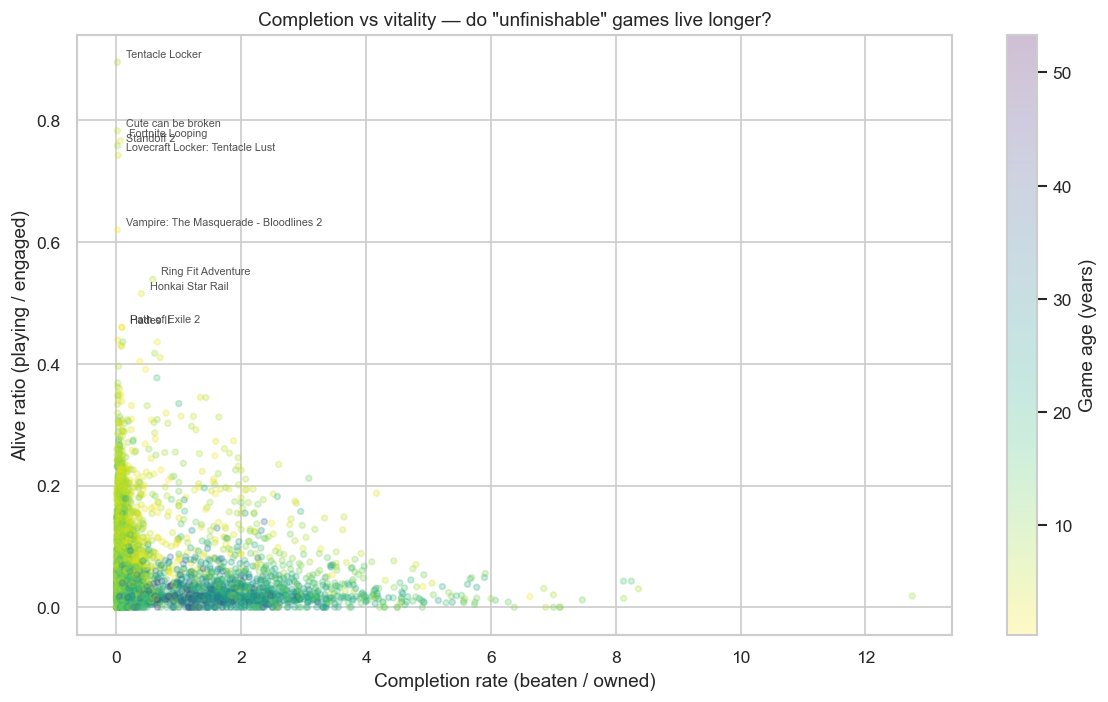

Correlation between completion rate and alive_ratio: -0.175

The relationship is negative — games that people 'finish' tend to die.
The top-left cluster (low completion, high vitality) is where the long-lived games sit.


In [17]:
# alive_ratio vs completion_rate
mask = (
    df['alive_ratio'].notna() &
    df['completion_rate'].notna() &
    (df['engaged'] >= 50)
)
plot_df = df[mask]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    plot_df['completion_rate'],
    plot_df['alive_ratio'],
    alpha=0.25, s=12, c=plot_df['game_age'], cmap='viridis_r'
)
plt.colorbar(scatter, label='Game age (years)', ax=ax)
ax.set_xlabel('Completion rate (beaten / owned)')
ax.set_ylabel('Alive ratio (playing / engaged)')
ax.set_title('Completion vs vitality — do "unfinishable" games live longer?')

# Label a few notable games
notable = plot_df.nlargest(10, 'alive_ratio')
for _, row in notable.iterrows():
    ax.annotate(row['name'], (row['completion_rate'], row['alive_ratio']),
                fontsize=6.5, alpha=0.8, xytext=(5, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

# Correlation
r = plot_df[['completion_rate', 'alive_ratio']].corr().iloc[0, 1]
print(f"Correlation between completion rate and alive_ratio: {r:.3f}")
print(f"\nThe relationship is negative — games that people 'finish' tend to die.")
print(f"The top-left cluster (low completion, high vitality) is where the long-lived games sit.")

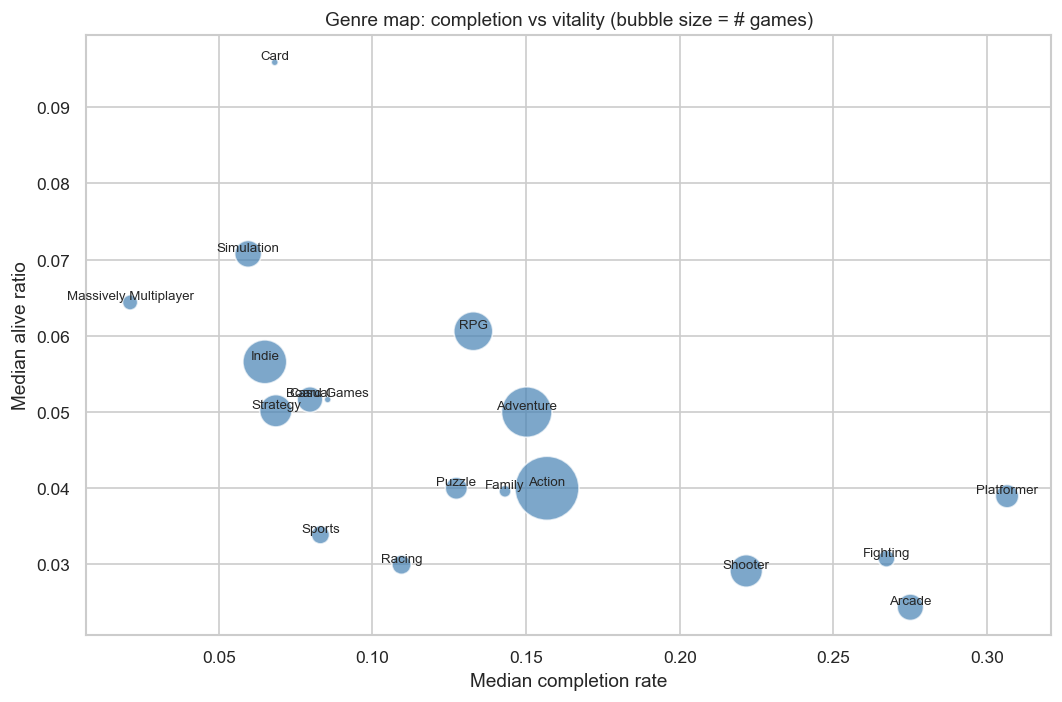

Genres cluster into two regimes:
  High completion, low vitality: Puzzle, Adventure, Platformer — play once, done.
  Low completion, high vitality: MMO, Sports, Simulation, Strategy — designed to be endless.

This suggests 'unfinishability' isn't a flaw — it's a feature of games that last.


In [18]:
# Same insight, by genre: median alive_ratio vs median completion_rate
genre_cross = (
    explode_col(df[df['alive_ratio'].notna() & (df['engaged'] >= 50)], 'genres')
    .groupby('genres')
    .agg(
        median_alive=('alive_ratio', 'median'),
        median_completion=('completion_rate', 'median'),
        n=('id', 'count')
    )
    .query('n >= 30')
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(genre_cross['median_completion'], genre_cross['median_alive'],
           s=genre_cross['n'] * 0.5, alpha=0.7, c='steelblue', edgecolors='white')

for genre, row in genre_cross.iterrows():
    ax.annotate(genre, (row['median_completion'], row['median_alive']),
                fontsize=8, ha='center', va='bottom')

ax.set_xlabel('Median completion rate')
ax.set_ylabel('Median alive ratio')
ax.set_title('Genre map: completion vs vitality (bubble size = # games)')
plt.tight_layout()
plt.show()

print(f"Genres cluster into two regimes:")
print(f"  High completion, low vitality: Puzzle, Adventure, Platformer — play once, done.")
print(f"  Low completion, high vitality: MMO, Sports, Simulation, Strategy — designed to be endless.")
print(f"\nThis suggests 'unfinishability' isn't a flaw — it's a feature of games that last.")

## 2.4 Community presence scales differently with age
Do long-lived games have disproportionate community signals relative to how old they are?

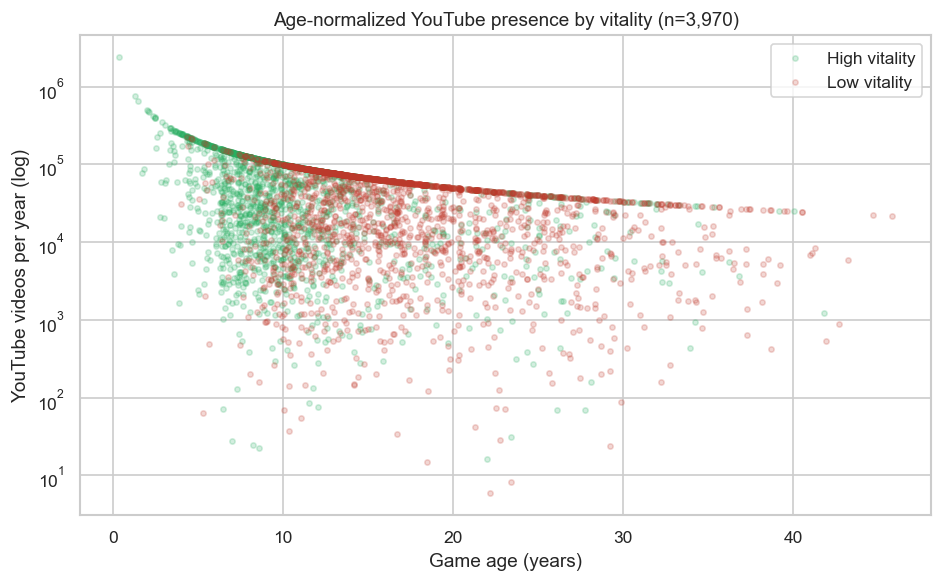

Median YouTube/year — high vitality: 51,713, low: 34,459
High-vitality games get 1.5× more YouTube activity per year of existence.

Coverage caveat: YouTube data available for 3970 / 12207 games (33%).


In [19]:
# Age-normalized community signal: youtube_count / game_age
df['youtube_per_year'] = np.where(
    df['youtube_count'].notna() & (df['game_age'] > 0),
    df['youtube_count'] / df['game_age'],
    np.nan
)

# Split into high-vitality vs low-vitality
mask = df['alive_ratio'].notna() & df['youtube_per_year'].notna() & (df['engaged'] >= 50)
plot_df = df[mask].copy()
plot_df['vitality_group'] = np.where(plot_df['alive_ratio'] > plot_df['alive_ratio'].median(), 'High vitality', 'Low vitality')

fig, ax = plt.subplots(figsize=(8, 5))
for group, color in [('High vitality', '#27ae60'), ('Low vitality', '#c0392b')]:
    subset = plot_df[plot_df['vitality_group'] == group]
    ax.scatter(subset['game_age'], subset['youtube_per_year'],
              alpha=0.2, s=10, c=color, label=group)

ax.set_yscale('log')
ax.set_xlabel('Game age (years)')
ax.set_ylabel('YouTube videos per year (log)')
ax.set_title(f'Age-normalized YouTube presence by vitality (n={mask.sum():,})')
ax.legend()
plt.tight_layout()
plt.show()

# Median comparison
medians = plot_df.groupby('vitality_group')['youtube_per_year'].median()
ratio = medians.get('High vitality', 0) / medians.get('Low vitality', 1)
print(f"Median YouTube/year — high vitality: {medians.get('High vitality', 0):,.0f}, low: {medians.get('Low vitality', 0):,.0f}")
print(f"High-vitality games get {ratio:.1f}× more YouTube activity per year of existence.")
print(f"\nCoverage caveat: YouTube data available for {mask.sum()} / {len(df)} games ({mask.mean()*100:.0f}%).")